# Multimodal (audio-visual) analysis
> This script is running for experiment with auditory and visual (objects) trials.

In [1]:
import datajoint as dj
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import itertools
import pandas as pd
import os
from IPython.display import display, HTML
from scipy.stats import sem

# Style of plots
small_size=8
medium_size=20
large_size=40
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['pdf.fonttype'] =42
mpl.rcParams['axes.grid']=False
mpl.rcParams['axes.titlesize']=small_size
mpl.rcParams["figure.titlesize"] = medium_size
mpl.rcParams['axes.labelsize']=small_size
mpl.rcParams['xtick.labelsize']=small_size
mpl.rcParams['ytick.labelsize']=small_size
mpl.rcParams['legend.fontsize']=small_size



dj.config["enable_python_native_blobs"] = True
dj.config['database.host'] = 'database.eflab.org:3306'
dj.config['database.password'] = os.getenv('DJ_PASSWORD')


schemata = {'exp'   : 'lab_experiments',
            'stim'  : 'lab_stimuli',
            'beh'   : 'lab_behavior',
            'inter' : 'lab_interface',
            'rec'   :'lab_recordings',
            'mice'  : 'lab_mice'}

# create a virtual module for every database schema that you are going to use
for schema, value in schemata.items():
    globals()[schema] = dj.create_virtual_module(schema, value, create_tables=True, create_schema=True)

from multimodal_functions import (
    get_condition_distribution,
    get_scatter_plot_modalities,
    get_visual_performance_summary, 
    plot_visual_performance_per_object,
    get_multimodal_performance_summary, 
    plot_multimodal_performance_per_object,
    get_auditory_performance_summary,
    plot_auditory_performance_per_object,
    get_linePlot_per_modality_across_sessions,
    calculate_response_type,
    obj215_trials
)

[2026-07-16 14:37:24,310][INFO]: DataJoint 0.14.6 connected to eflab@database.eflab.org:3306


In [8]:
# complete the key
animal_id = 299
from_session = 634
to_session = 800

# define the difficulty level
# one difficulty: [2] or multiple difficulties: [1,2,3]
difficulty = [1,2,3,4]

# exclude sessions from plotting
# manual_exclusion_sessions = list(range(180, 280)) + [318,320,322]
manual_exclusion_sessions = []

## Distribution of each condition across sessions

In [9]:
get_condition_distribution(animal_id, from_session, to_session, stim, exp, manual_exclusion_sessions, difficulty, incl_aborts=False)

[2026-07-19 23:56:40,244][WARNING]: Reconnecting to MySQL server.


OperationalError: (2003, "Can't connect to MySQL server on 'database.eflab.org' (timed out)")

## Rewards, Punish and Aborts across sessions

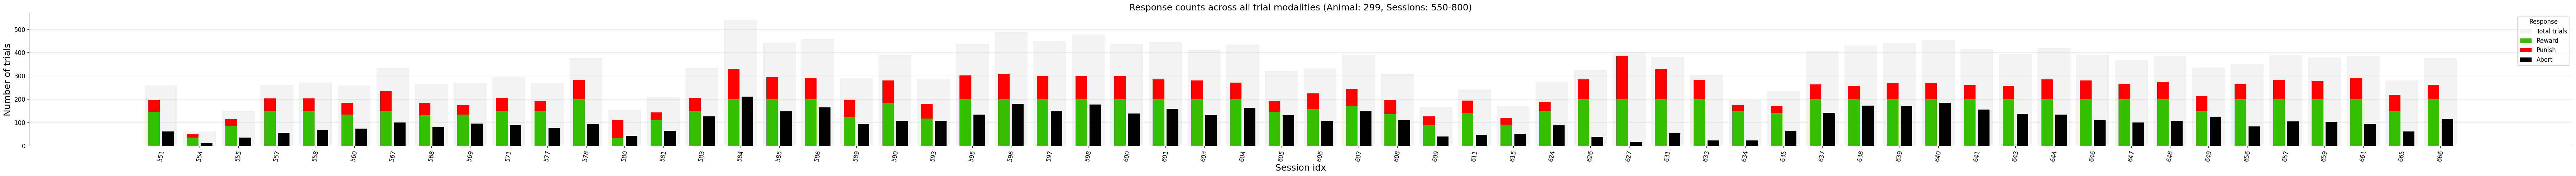

In [5]:
calculate_response_type(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,)

## Scatter plot beetween modalites across sessions

/Users/anastasiosgratsakis/projects/eflab_project/multimodal_analysis/multimodal_functions.py:631: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


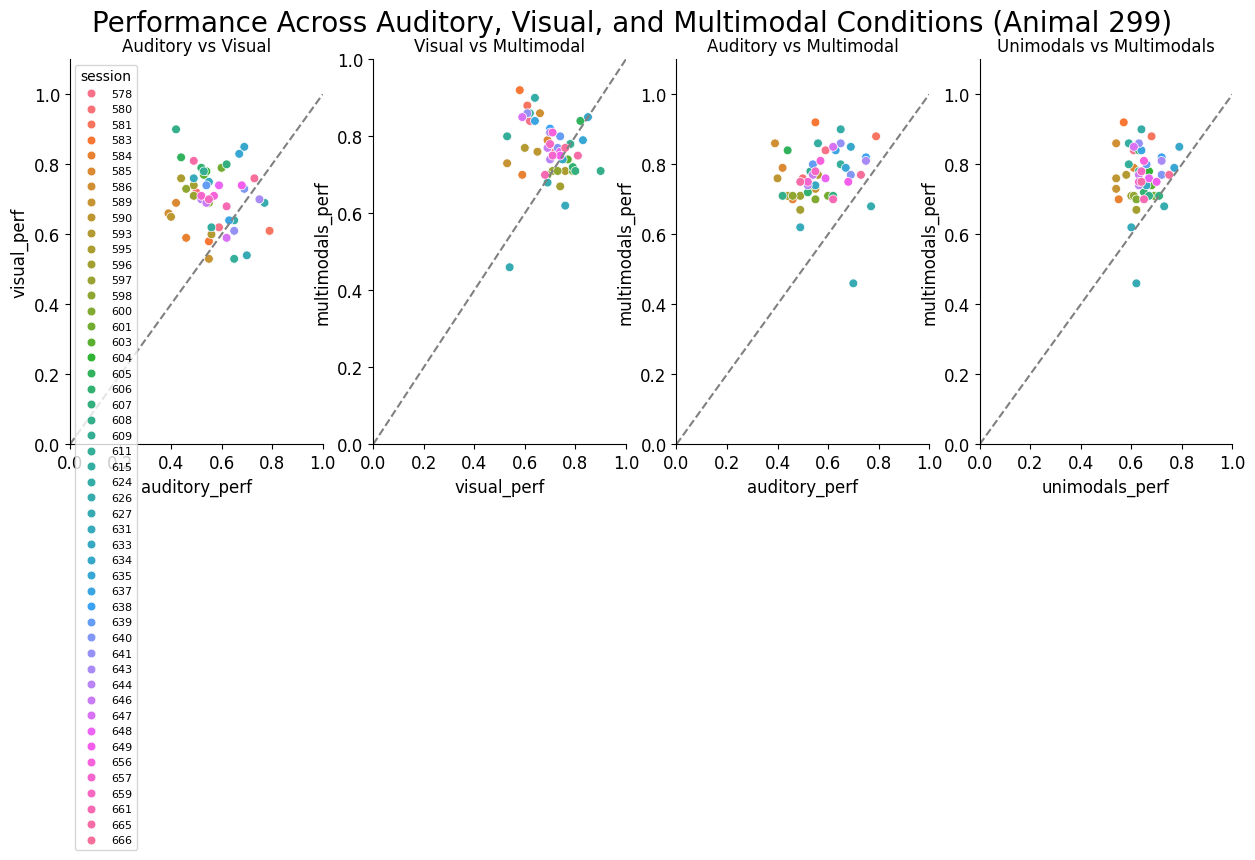

Skipped sessions (missing one or more modalities): [550, 551, 552, 553, 554, 555, 557, 558, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 571, 577, 617, 618, 619, 620, 621]


,session,auditory_perf,visual_perf,multi_perf,uni_perf
0,578,0.59,0.62,0.84,0.61
1,580,0.50,0.72,0.76,0.67
2,581,0.79,0.61,0.88,0.68
3,583,0.55,0.58,0.92,0.57
4,584,0.46,0.59,0.70,0.55
5,585,0.42,0.69,0.79,0.61
6,586,0.39,0.66,0.86,0.54
7,589,0.55,0.53,0.73,0.54
8,590,0.40,0.65,0.76,0.54
9,593,0.56,0.60,0.77,0.58


In [6]:
# Scatter plot comparing the performance across modalities. 
get_scatter_plot_modalities(animal_id,from_session,to_session,stim, exp,manual_exclusion_sessions,difficulty)

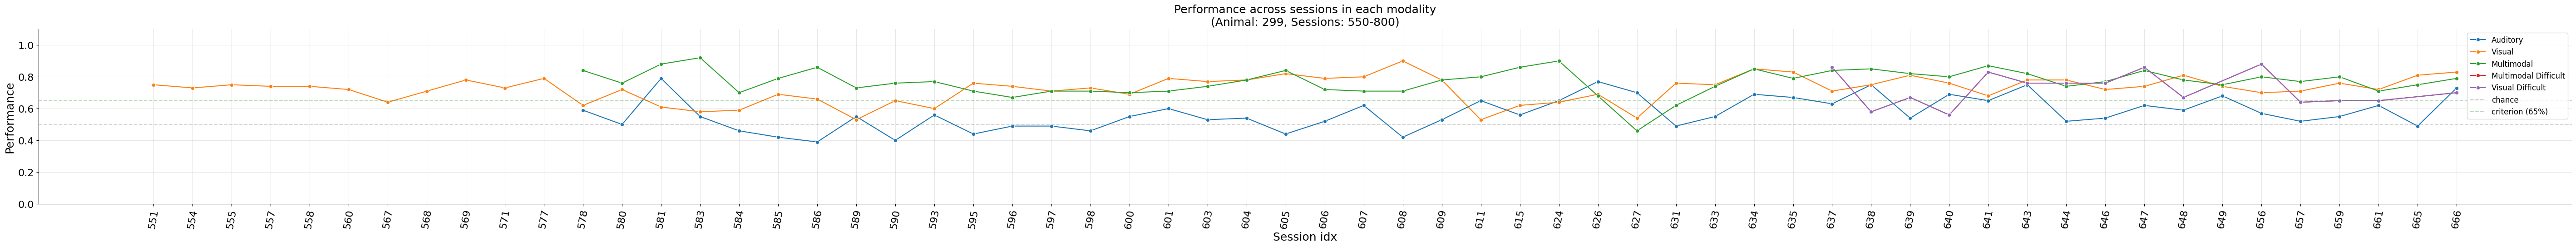

In [7]:
get_linePlot_per_modality_across_sessions(animal_id,from_session,to_session,stim,exp,manual_exclusion_sessions,difficulty,criterion=0.65)

## Performance per object id in each modality across sessions

In [ ]:
# Define the key (dict) for unimodal-visual, unimodal-auditory and multimodal trials
# Parameters: animal_id (int), session (int) as a range (from_session, to_session), 
# difficulty level (either one difficulty [1] or multiple [1,2]), object_ids (list), excluded_sessions (list)
# required parameters: animal_id, sessions, difficulties
# defaulted object_ids parameters: [211,212,213,214,215,216,217,218,219]
key = {
    'animal_id': animal_id,
    'sessions': (from_session, to_session), 
    'difficulties': difficulty, 
    'stim': stim,
    'exp': exp,
    'excluded_sessions': manual_exclusion_sessions
}

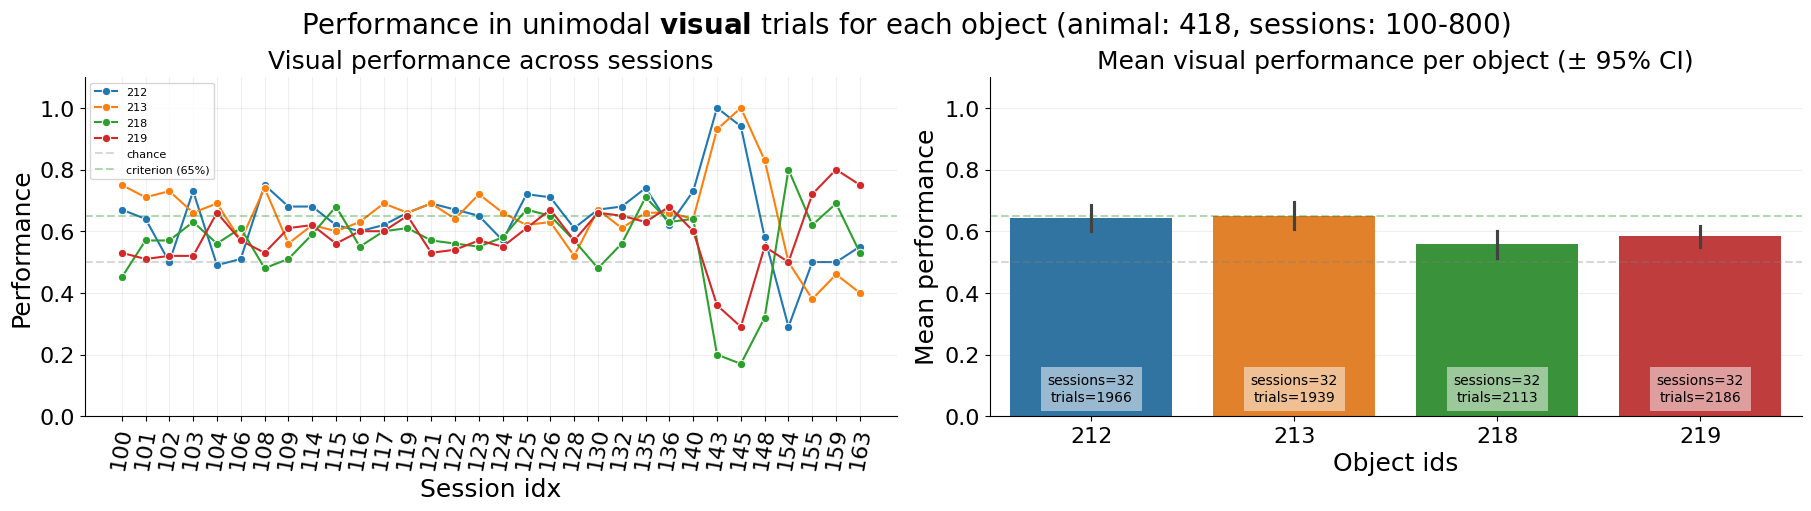

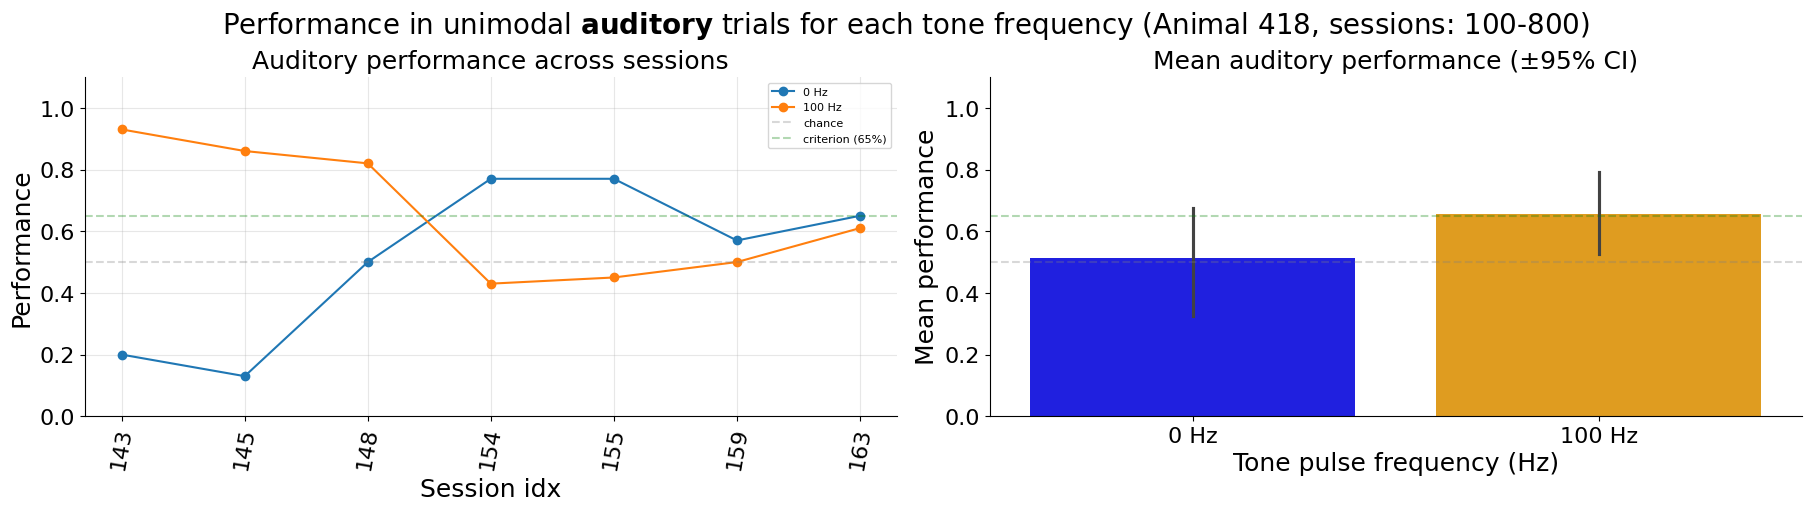

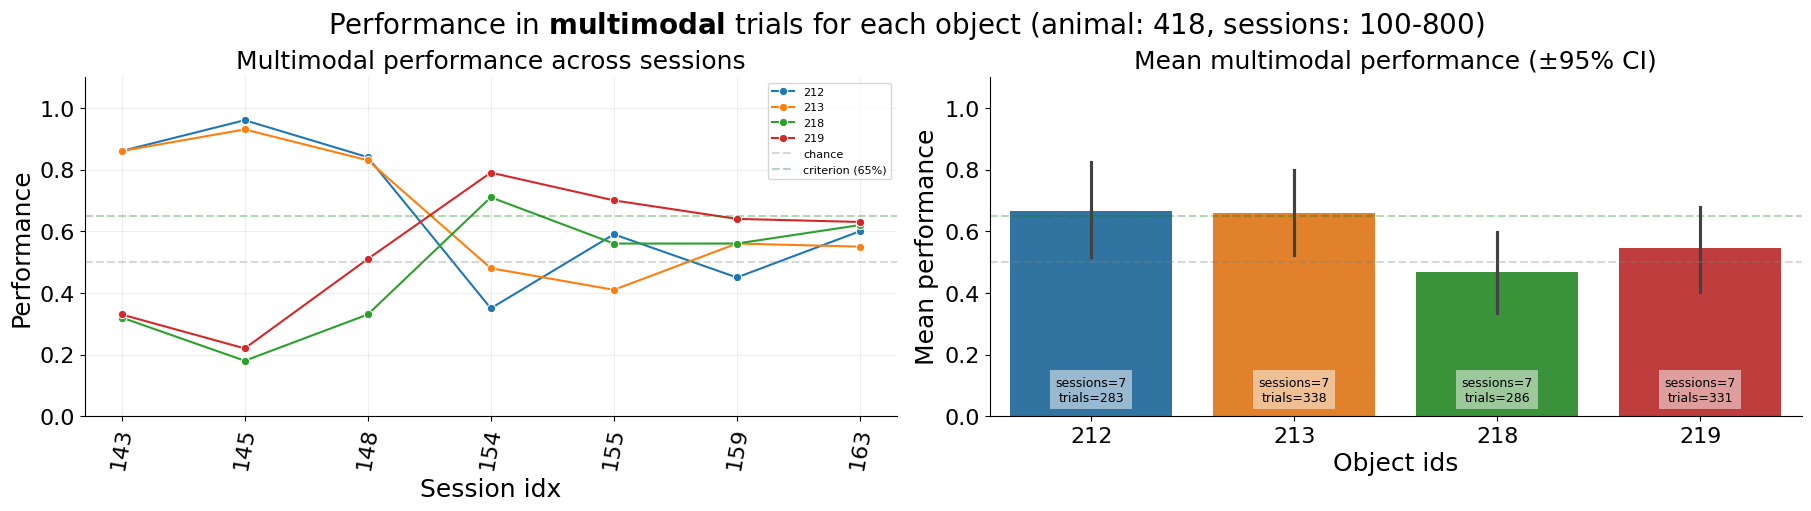

In [ ]:
# Print per-object DataFrames summarizing number of session trials, valid per object trials,
# percentage per object in the session, object performance, rewarded/punished/aborted trials
# Performace in unimodal visual trials:
# get_visual_performance_summary(key) 
# Performance in unimodal auditory trials: 
# parameters: key (dict), pulse_freq ('all', '0', '100')
# get_auditory_performance_summary(key)
# Performace in multimodal trials:
# get_multimodal_performance_summary(key) 

# Line and bar plot of unimodal-visual and multimodal performance across sessions per object. 
# Parameters: key (dict), criterion (float), 
# default criterion: 0.65
plot_visual_performance_per_object(key)
plot_auditory_performance_per_object(key)
plot_multimodal_performance_per_object(key)

## Analysis of obj. 50-50 trials

Object 50-50 (`obj_id 215`) is a morph between two pure objects: Bunny Head (`obj_id 219`) and Star Trek (`obj_id 211`) with equal contribution of both objects.

In [ ]:
# Print details in multimodal trials with object 215 across sessions
# Parameters: animal_id (int), session (dict)
# Output: animal_id, session, date, multi_obj215_trials, multimodal performance, rewarded, punished and aborted trials
# correct and incorrect licks (based on the corresponed tone: port 1 - 100 Hz, port 2 - 0 Hz)
obj215_trials.get_multimodal_trials_summary(animal_id,from_session,to_session,manual_exclusion_sessions,difficulty)

,animal_id,session,date,multi_obj215_trials,multi_perf,rewards,punishments,abortions,correct_licks,incorrect_licks,port1_licks,port2_licks
0,299,634,2026-06-24,17,0.47,17,0,0,8,9,27,65
1,299,635,2026-06-25,16,0.38,16,0,0,6,10,48,67


In [ ]:
# Print details in visual trials with object 215 across sessions
# Parameters: animal_id (int), session (dict)
# Output: animal_id, session, date, multi_obj215_trials, visual performance, rewarded, punished and aborted trials
# port1_first_lick: number of trials with first lick in port 1
# port2_first_lick: number of trials with first lick in port 2
obj215_trials.get_visual_trials_summary(animal_id,from_session,to_session,manual_exclusion_sessions,difficulty)

,animal_id,session,date,visual_obj215_trials,rewards,punishments,abortions,port1_first_lick,port2_first_lick,port1_licks,port2_licks
0,299,634,2026-06-24,17,17,0,0,3,14,27,65
1,299,635,2026-06-25,16,16,0,0,8,8,48,67


## Analysis of trials without any stimuli